<h2><center><b> Worldcup comparison</b> </center></h2>


<h4> <u>Working title:</u> <br>
Does having Ballon d'Or players increase a nation's chance of winning the World Cup,
or does winning the World Cup increase a player's chance of receiving Ballon d'Or votes? </h4>

<p>Ballon d'Or & World Cup – Datenanalyse</p>

In [98]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency, ttest_ind, mannwhitneyu
from scipy.stats import chi2_contingency, fisher_exact

Load data from csv files


In [99]:
players = pd.read_csv("players.csv")
ballondor = pd.read_csv("ballondor_all_ranked.csv")
standing = pd.read_csv("tournament_standings.csv")
matches_players = pd.read_csv("player_appearances.csv")

Show the first 10 entries of each tabel

In [100]:
players.head()
players

,key_id,player_id,family_name,given_name,birth_date,female,goal_keeper,defender,midfielder,forward,count_tournaments,list_tournaments,player_wikipedia_link
0,1,P-35894,A'Court,Alan,1934-09-30,0,0,0,0,1,1,1958,https://en.wikipedia.org/wiki/Alan_A%27Court
1,2,P-29915,Aarønes,Ann Kristin,1973-01-19,1,0,0,1,1,2,"1995, 1999",https://en.wikipedia.org/wiki/Ann_Kristin_Aar%...
2,3,P-03484,Aaronson,Brenden,2000-10-22,0,0,0,0,1,1,2022,https://en.wikipedia.org/wiki/Brenden_Aaronson
3,4,P-04189,Abadzhiev,Stefan,1934-07-03,0,0,0,0,1,1,1966,https://en.wikipedia.org/wiki/Stefan_Abadzhiev
4,5,P-03523,Abalo,Jean-Paul,1975-06-26,0,0,1,0,0,1,2006,https://en.wikipedia.org/wiki/Jean-Paul_Abalo
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10396,10397,P-31085,Żurkowski,Szymon,1997-09-25,0,0,0,1,0,1,2022,https://en.wikipedia.org/wiki/Szymon_%C5%BBurk...
10397,10398,P-59568,Zurrer,Emily,1987-07-12,1,0,1,0,0,2,"2011, 2015",https://en.wikipedia.org/wiki/Emily_Zurrer
10398,10399,P-51653,Zusi,Graham,1986-08-18,0,0,0,1,0,1,2014,https://en.wikipedia.org/wiki/Graham_Zusi
10399,10400,P-05885,Zygmantovich,Andrei,1962-12-02,0,0,0,1,0,1,1990,https://en.wikipedia.org/wiki/Andrei_Zygmantovich


In [101]:
ballondor.head()

,Year,Rank,Player
0,1998,1,Zinedine Zidane
1,1998,2,Davor Šuker
2,1998,3,Ronaldo
3,1998,4,Michael Owen
4,1998,5,Rivaldo


In [102]:
standing.head()

,key_id,tournament_id,tournament_name,position,team_id,team_name,team_code
0,1,WC-1930,1930 FIFA Men's World Cup,1,T-84,Uruguay,URY
1,2,WC-1930,1930 FIFA Men's World Cup,2,T-03,Argentina,ARG
2,3,WC-1930,1930 FIFA Men's World Cup,3,T-83,United States,USA
3,4,WC-1930,1930 FIFA Men's World Cup,4,T-87,Yugoslavia,YUG
4,5,WC-1934,1934 FIFA Men's World Cup,1,T-41,Italy,ITA


In [103]:
matches_players.head()

,key_id,tournament_id,tournament_name,match_id,match_name,match_date,stage_name,group_name,team_id,team_name,...,home_team,away_team,player_id,family_name,given_name,shirt_number,position_name,position_code,starter,substitute
0,1,WC-1970,1970 FIFA Men's World Cup,M-1970-01,Mexico vs Soviet Union,1970-05-31,group stage,Group 1,T-46,Mexico,...,1,0,P-66980,Calderón,Ignacio,1,goal keeper,GK,1,0
1,2,WC-1970,1970 FIFA Men's World Cup,M-1970-01,Mexico vs Soviet Union,1970-05-31,group stage,Group 1,T-46,Mexico,...,1,0,P-64553,Peña,Gustavo,3,defender,DF,1,0
2,3,WC-1970,1970 FIFA Men's World Cup,M-1970-01,Mexico vs Soviet Union,1970-05-31,group stage,Group 1,T-46,Mexico,...,1,0,P-42664,Pérez,Mario,5,defender,DF,1,0
3,4,WC-1970,1970 FIFA Men's World Cup,M-1970-01,Mexico vs Soviet Union,1970-05-31,group stage,Group 1,T-46,Mexico,...,1,0,P-69898,Hernández,Guillermo,6,midfielder,MF,1,0
4,5,WC-1970,1970 FIFA Men's World Cup,M-1970-01,Mexico vs Soviet Union,1970-05-31,group stage,Group 1,T-46,Mexico,...,1,0,P-56971,Salgado,Horacio López,10,forward,FW,1,0


Filter for Men's worldcup du to tabel containing Womens worldcup as well and filter the year out of the title to merge it later.<br>
As well convert the year in the ballondor tabel to an integer

In [104]:

wc_standings = standing[standing["tournament_name"].str.contains("FIFA Men's World Cup", case=False, na=False)].copy()
wc_matches_players = matches_players[matches_players["tournament_name"].str.contains("FIFA Men's World Cup", case=False, na=False)].copy()

wc_standings["year"] = wc_standings["tournament_name"].str.extract(r"(\d{4})").astype(int)
wc_matches_players["year"] = wc_matches_players["tournament_name"].str.extract(r"(\d{4})").astype(int)

ballondor["Year"] = ballondor["Year"].astype(int)


Just printing the years of the cup with the amount of teams in the standing tabel (always 4 becaus standing.csv has 4 entries for each tournament)

In [105]:
wc_standings["year"].value_counts().sort_index()


year
1930    4
1934    4
1938    4
1950    4
1954    4
1958    4
1962    4
1966    4
1970    4
1974    4
1978    4
1982    4
1986    4
1990    4
1994    4
1998    4
2002    4
2006    4
2010    4
2014    4
2018    4
2022    4
Name: count, dtype: int64

Unify the player names of both list wc_matches_players and ballondor. <br>
For wc_matches_player append both names together.

In [106]:

wc_matches_players["player_fullname"] = (
    wc_matches_players["given_name"].fillna("") + " " + wc_matches_players["family_name"].fillna("")
).str.strip().str.lower()


ballondor["player_fullname"] = ballondor["Player"].str.strip().str.lower()


Print the first 10 entries of both tabel colums "player_fullname"

In [107]:
print(ballondor["player_fullname"].head(10))
print(wc_matches_players["player_fullname"].head(10))

0      zinedine zidane
1          davor šuker
2              ronaldo
3         michael owen
4              rivaldo
5    gabriel batistuta
6        lilian thuram
7         edgar davids
8      dennis bergkamp
9      marcel desailly
Name: player_fullname, dtype: object
0         ignacio calderón
1             gustavo peña
2              mario pérez
3      guillermo hernández
4    horacio lópez salgado
5            josé vantolrá
6            javier guzmán
7            héctor pulido
8            mario velarde
9          javier valdivia
Name: player_fullname, dtype: object


Check for duplicates

In [108]:
wc_matches_players["player_fullname"].nunique(), len(wc_matches_players)

(5079, 20618)

In [109]:
ballondor["player_fullname"].nunique(), len(ballondor)

(170, 390)

Get rid of duplicates and make every entry for player in tournament unique.<br>
<u>Important:</u> One player has more than one appereance in the same WC tournament. We only need one of his entries and not all so make it unique

In [110]:

unique_players = (
    wc_matches_players
    .groupby(["year", "player_id", "player_fullname", "team_id", "team_name"], as_index=False)
    .size()  
)

unique_players.head()


,year,player_id,player_fullname,team_id,team_name,size
0,1970,P-00086,roberto rivas,T-27,El Salvador,3
1,1970,P-00119,gigi riva,T-41,Italy,6
2,1970,P-00746,tom turesson,T-74,Sweden,2
3,1970,P-01172,dobromir zhechev,T-10,Bulgaria,2
4,1970,P-02102,anatoliy byshovets,T-72,Soviet Union,4


Merge WM players and ballondor candidates of the same year.<br>
With this merge we link each WM Player with the ballondor ranking of that same year<br>
Resulting tabel gives information, if the player has been bd candidate or winner in the year of the wc and the year and rank.

In [111]:

players_bd_same = unique_players.merge(
    ballondor[["Year", "player_fullname", "Rank"]],
    how="left",
    left_on=["year", "player_fullname"],
    right_on=["Year", "player_fullname"],
    suffixes=("", "_bd_same")
)

players_bd_same["is_bd_candidate_same_year"] = players_bd_same["Rank"].notna().astype(int)
players_bd_same["is_bd_winner_same_year"]   = (players_bd_same["Rank"] == 1).astype(int)

players_bd_same.head()

,year,player_id,player_fullname,team_id,team_name,size,Year,Rank,is_bd_candidate_same_year,is_bd_winner_same_year
0,1970,P-00086,roberto rivas,T-27,El Salvador,3,NaN,NaN,0,0
1,1970,P-00119,gigi riva,T-41,Italy,6,NaN,NaN,0,0
2,1970,P-00746,tom turesson,T-74,Sweden,2,NaN,NaN,0,0
3,1970,P-01172,dobromir zhechev,T-10,Bulgaria,2,NaN,NaN,0,0
4,1970,P-02102,anatoliy byshovets,T-72,Soviet Union,4,NaN,NaN,0,0


Same as before but only for the one year befor the world cup to look for the second Hypotheses.<br>
We want to look if the ballondor winner of the previous year has an influence on the world cup winner.

In [112]:
unique_players["year_minus_1"] = unique_players["year"] - 1

players_bd_before = unique_players.merge(
    ballondor[["Year", "player_fullname", "Rank"]],
    how="left",
    left_on=["year_minus_1", "player_fullname"],
    right_on=["Year", "player_fullname"],
    suffixes=("", "_bd_before")
)

players_bd_before["is_bd_candidate_before"] = players_bd_before["Rank"].notna().astype(int)
players_bd_before["is_bd_winner_before"]   = (players_bd_before["Rank"] == 1).astype(int)

players_bd_before.head()


,year,player_id,player_fullname,team_id,team_name,size,year_minus_1,Year,Rank,is_bd_candidate_before,is_bd_winner_before
0,1970,P-00086,roberto rivas,T-27,El Salvador,3,1969,NaN,NaN,0,0
1,1970,P-00119,gigi riva,T-41,Italy,6,1969,NaN,NaN,0,0
2,1970,P-00746,tom turesson,T-74,Sweden,2,1969,NaN,NaN,0,0
3,1970,P-01172,dobromir zhechev,T-10,Bulgaria,2,1969,NaN,NaN,0,0
4,1970,P-02102,anatoliy byshovets,T-72,Soviet Union,4,1969,NaN,NaN,0,0


Define variable to store wc standings without duplicates

In [130]:
team_info = wc_standings[["year", "team_id", "team_name", "team_code", "position"]].drop_duplicates()
team_info.head(10)

,year,team_id,team_name,team_code,position
0,1930,T-84,Uruguay,URY,1
1,1930,T-03,Argentina,ARG,2
2,1930,T-83,United States,USA,3
3,1930,T-87,Yugoslavia,YUG,4
4,1934,T-41,Italy,ITA,1
5,1934,T-21,Czechoslovakia,CSK,2
6,1934,T-31,Germany,DEU,3
7,1934,T-05,Austria,AUT,4
8,1938,T-41,Italy,ITA,1
9,1938,T-36,Hungary,HUN,2


Add wc team rank from team info to the player of tabel player_bd_same.<br>
We match players ot their teams by year, team id und team_name.<br>
In this way we can check if the players wc rank has influence of ballondor ranking.

In [114]:
players_bd_same = players_bd_same.merge(
    team_info[["year", "team_id", "team_name", "position"]].drop_duplicates(),
    on=["year", "team_id", "team_name"],
    how="left"
)

Create new column to store if wc winner = 1 or not = 0

In [132]:
players_bd_same["is_worldcup_winner_team"] = (players_bd_same["position"] == 1).astype(int)
print(players_bd_same["is_worldcup_winner_team"].head(10))


0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
9    1
Name: is_worldcup_winner_team, dtype: int64


create tabel bd_ranks.<br>
Get all players that have a Ballondor ranking in the WC year and therefore are in the Top 15.<br>
Get the variable to show if the player is a wc winner of the same year.

In [116]:
bd_ranks = players_bd_same.loc[
    players_bd_same["Rank"].notna(),
    ["Rank", "is_worldcup_winner_team"]
].copy()

bd_ranks["Rank"] = bd_ranks["Rank"].astype(int)
bd_ranks["is_worldcup_winner_team"] = bd_ranks["is_worldcup_winner_team"].astype(int)

bd_ranks.head()


,Rank,is_worldcup_winner_team
2582,8,0
2631,11,0
2681,12,1
2719,8,0
2743,4,0


Count how many ballondor candidates each wc year has had.

In [117]:
players_bd_same.groupby("year")["is_bd_candidate_same_year"].sum()


year
1970     0
1974     0
1978     0
1982     0
1986     0
1990     0
1994     0
1998    13
2002    10
2006    11
2010    14
2014    12
2018    14
2022     7
Name: is_bd_candidate_same_year, dtype: int64

In [118]:
players_bd_before.groupby("year")["is_bd_candidate_before"].sum()


year
1970     0
1974     0
1978     0
1982     0
1986     0
1990     0
1994     0
1998     0
2002    11
2006     9
2010    10
2014     8
2018    12
2022     7
Name: is_bd_candidate_before, dtype: int64

Hypotheses 1:<br>
This block aggregates player-level information into team-level statistics
for each World Cup year. After merging player data with team placements,
we compute: <br>

<ul>
    <li>number of players per team (`num_players`)</li>
    <li>number and presence of Ballon d'Or candidates from the previous year</li>
    <li>number and presence of Ballon d'Or winners from the previous year</li>
    <li>final World Cup placement (`position`)</li>
    <li>whether the team became World Cup champion (`is_worldcup_winner`)</li>
</ul>



In [ ]:
team_summary_before = (
    players_bd_before
    .merge(team_info, on=["year", "team_id", "team_name"], how="left")
    .groupby(["year", "team_id", "team_name", "team_code"], as_index=False)
    .agg(
        num_players                  = ("player_id", "nunique"),
        num_bd_candidates_before     = ("is_bd_candidate_before", "sum"),
        has_bd_candidate_before      = ("is_bd_candidate_before", lambda x: x.any()),
        num_bd_winners_before        = ("is_bd_winner_before", "sum"),
        has_bd_winner_before         = ("is_bd_winner_before", lambda x: x.any()),
        position                     = ("position", "first")  
    )
)

team_summary_before["is_worldcup_winner"] = (team_summary_before["position"] == 1).astype(int)

team_summary_before.tail()


,year,team_id,team_name,team_code,num_players,num_bd_candidates_before,has_bd_candidate_before,num_bd_winners_before,has_bd_winner_before,position,is_worldcup_winner
51,2018,T-30,France,FRA,21,2,True,0,False,1.0,1
52,2022,T-03,Argentina,ARG,24,1,True,1,True,1.0,1
53,2022,T-18,Croatia,HRV,21,0,False,0,False,3.0,0
54,2022,T-30,France,FRA,24,1,True,0,False,2.0,0
55,2022,T-47,Morocco,MAR,25,0,False,0,False,4.0,0


Same as done above just for Hypotheses 2:

In [ ]:

team_summary_same = (
    players_bd_same
    .groupby(["year", "team_id", "team_name"], as_index=False)
    .agg(
        num_players            = ("player_id", "nunique"),
        num_bd_candidates_same = ("is_bd_candidate_same_year", "sum"),
        has_bd_candidate_same  = ("is_bd_candidate_same_year", lambda x: x.any()),
        num_bd_winners_same    = ("is_bd_winner_same_year", "sum"),
        has_bd_winner_same     = ("is_bd_winner_same_year", lambda x: x.any())
    )
)


team_summary_same = team_summary_same.merge(
    team_info[["year", "team_id", "position"]],
    on=["year", "team_id"],
    how="left"
)

team_summary_same["is_worldcup_winner"] = (team_summary_same["position"] == 1).astype(int)

team_summary_same.tail(10)


,year,team_id,team_name,num_players,num_bd_candidates_same,has_bd_candidate_same,num_bd_winners_same,has_bd_winner_same,position,is_worldcup_winner
358,2022,T-63,Saudi Arabia,23,0,False,0,False,NaN,0
359,2022,T-65,Senegal,20,0,False,0,False,NaN,0
360,2022,T-66,Serbia,22,0,False,0,False,NaN,0
361,2022,T-71,South Korea,21,0,False,0,False,NaN,0
362,2022,T-73,Spain,21,0,False,0,False,NaN,0
363,2022,T-75,Switzerland,24,0,False,0,False,NaN,0
364,2022,T-79,Tunisia,21,0,False,0,False,NaN,0
365,2022,T-83,United States,20,0,False,0,False,NaN,0
366,2022,T-84,Uruguay,19,0,False,0,False,NaN,0
367,2022,T-85,Wales,18,0,False,0,False,NaN,0


Groupby years to see for the years befor wc how many ballondor candidates there have been and how many winners

In [ ]:
team_summary_before.groupby("year")[["num_bd_candidates_before", "num_bd_winners_before"]].sum()

,num_bd_candidates_before,num_bd_winners_before
year,,
1970,0,0
1974,0,0
1978,0,0
1982,0,0
1986,0,0
1990,0,0
1994,0,0
1998,0,0
2002,1,0


Groupby years to see how mand ballondor candidates and winners in the same year as wc there are

In [122]:
team_summary_same.groupby("year")[["num_bd_candidates_same", "num_bd_winners_same"]].sum()


,num_bd_candidates_same,num_bd_winners_same
year,,
1970,0,0
1974,0,0
1978,0,0
1982,0,0
1986,0,0
1990,0,0
1994,0,0
1998,13,1
2002,10,0


Hypothesis 1: <br>
BD candidates in the previous year → influence on WM win?<br>

Construct a 2x2 matrix tabel to compare possibilitys:

<ul> 
    <li>is_woldcup_winner = 1 → has won wc</li>
    <li>has_bd_winner_before = 1 → has won bd year before wc</li>
</ul>
<br>
This shows how often the winning team has a ballondor winner in their team and how often not and of there is even a correlation.<br>
Apply Fishers Exact Test to determin the statistical significance assosiated between the 2 variables.



In [ ]:
cont_before = pd.crosstab(
    team_summary_before["is_worldcup_winner"],
    team_summary_before["has_bd_winner_before"]
)

print("Kontingenztafel – Vorjahres BD-Gewinner vs WM-Sieg:")
print(cont_before)

oddsratio_before, p_before = fisher_exact(cont_before)
print("Fisher Exact Test – befor:")
print("Odds Ratio:", oddsratio_before)
print("p-Value:", p_before)

Kontingenztafel – Vorjahres-BD-Gewinner vs. WM-Sieg:
has_bd_winner_before  False  True 
is_worldcup_winner                
0                        42      0
1                        13      1
Fisher Exact Test – Vorjahr:
Odds Ratio: inf
p-Wert: 0.25


Hypothesis 2:<br>
WM win → Better Ballon d’Or ranking in the same year?<br>
Prep ballndor data set<br>

First create a colum to have a binary value to check if the player is wc winner.<br>
Then extract players how have a ranking in ballondor of the year of wc.<br>
Therefor we only use two Variables "Rank" and "is_worldcup_winner"<br>



In [ ]:
players_bd_same["is_worldcup_winner_team"] = (players_bd_same["position"] == 1).astype(int)

bd_ranks = players_bd_same.loc[
    players_bd_same["Rank"].notna(),
    ["Rank", "is_worldcup_winner_team"]
].copy()

bd_ranks["Rank"] = bd_ranks["Rank"].astype(int)
bd_ranks["is_worldcup_winner_team"] = bd_ranks["is_worldcup_winner_team"].astype(int)

bd_ranks.head()


,Rank,is_worldcup_winner_team
2582,8,0
2631,11,0
2681,12,1
2719,8,0
2743,4,0


Spliting ballondor ranked players it the two groups where one is the winner of wc and the rest in a dfferent group. <br>
These two distributions are required for the Mann–Whitney U test, which examines
whether players from World Cup winning teams achieve significantly better/lower Ballon d'Or rankings in the same year

In [125]:
winner_ranks = bd_ranks[bd_ranks["is_worldcup_winner_team"] == 1]["Rank"]
other_ranks  = bd_ranks[bd_ranks["is_worldcup_winner_team"] == 0]["Rank"]


Convert to integer

In [126]:
winner_ranks = winner_ranks.astype(int)
other_ranks  = other_ranks.astype(int)

In [127]:

stat, p = mannwhitneyu(winner_ranks, other_ranks, alternative="two-sided")
print("Mann-Whitney U:", stat)
print("p-Wert:", p)


Mann-Whitney U: 702.5
p-Wert: 0.9031360159041415


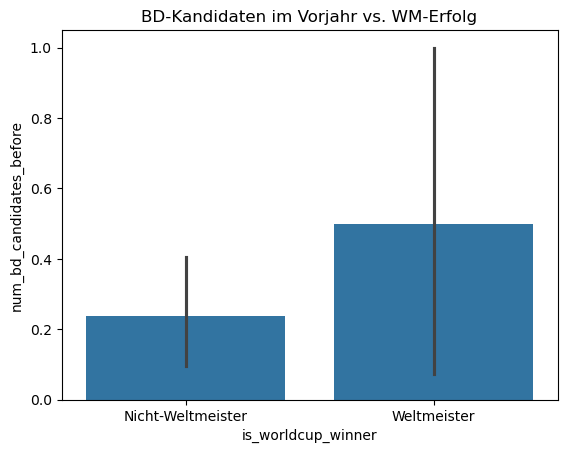

In [128]:
sns.barplot(data=team_summary_before, x="is_worldcup_winner", y="num_bd_candidates_before")
plt.xticks([0,1], ["Nicht-Weltmeister", "Weltmeister"])
plt.title("BD-Kandidaten im Vorjahr vs. WM-Erfolg")
plt.show()


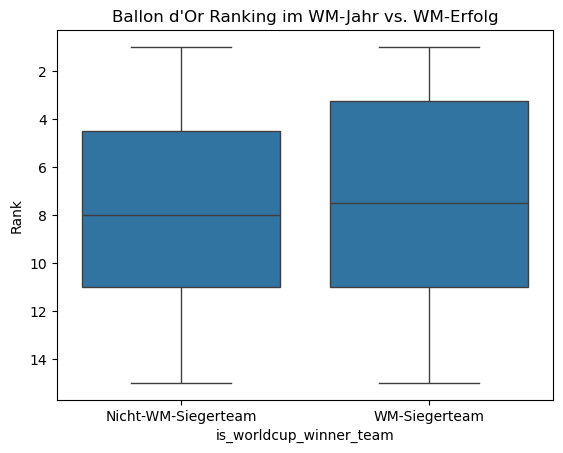

In [ ]:
sns.boxplot(data=bd_ranks, x="is_worldcup_winner_team", y="Rank")
plt.xticks([0,1], ["Nicht-WM-Siegerteam", "WM-Siegerteam"])
plt.gca().invert_yaxis()  
plt.title("Ballon d'Or Ranking im WM-Jahr vs. WM-Erfolg")
plt.show()


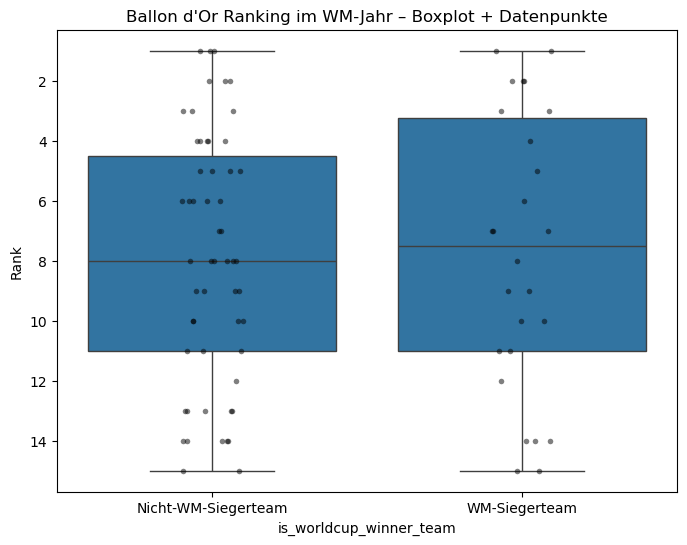

In [134]:
plt.figure(figsize=(8,6))
sns.boxplot(data=bd_ranks, x="is_worldcup_winner_team", y="Rank", showfliers=False)
sns.stripplot(data=bd_ranks, x="is_worldcup_winner_team", y="Rank", color="black", size=4, alpha=0.5)
plt.gca().invert_yaxis()
plt.xticks([0, 1], ["Nicht-WM-Siegerteam", "WM-Siegerteam"])
plt.title("Ballon d'Or Ranking im WM-Jahr – Boxplot + Datenpunkte")
plt.show()


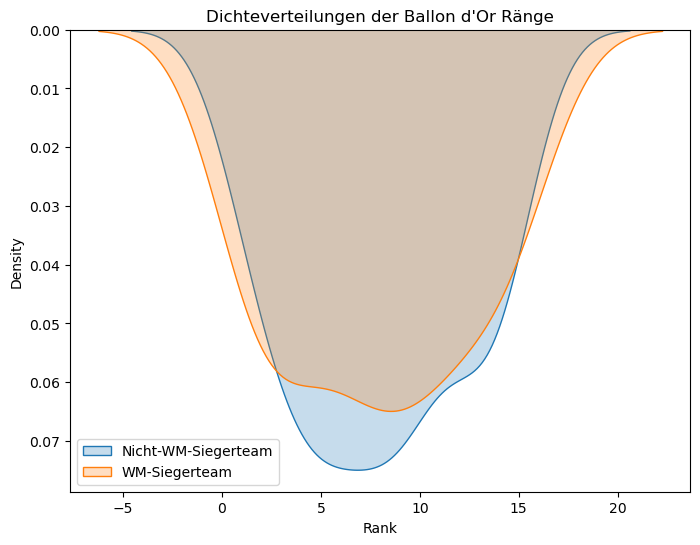

In [135]:
plt.figure(figsize=(8,6))
sns.kdeplot(data=bd_ranks[bd_ranks["is_worldcup_winner_team"] == 0]["Rank"], label="Nicht-WM-Siegerteam", fill=True)
sns.kdeplot(data=bd_ranks[bd_ranks["is_worldcup_winner_team"] == 1]["Rank"], label="WM-Siegerteam", fill=True)
plt.gca().invert_yaxis()
plt.title("Dichteverteilungen der Ballon d'Or Ränge")
plt.legend()
plt.show()


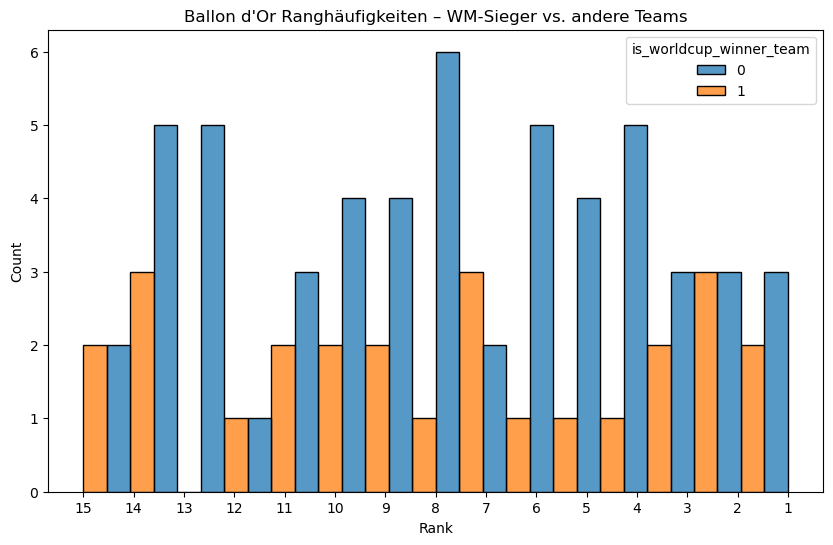

In [138]:
plt.figure(figsize=(10,6))
sns.histplot(bd_ranks, x="Rank", hue="is_worldcup_winner_team", multiple="dodge", bins=15)
plt.gca().invert_xaxis()
plt.title("Ballon d'Or Ranghäufigkeiten – WM-Sieger vs. andere Teams")
plt.xticks(range(1, 16))
plt.show()
